### Install and Load Required Packages
We need the psych library for reliability analysis (Cronbach's Alpha) and GPArotation for factor analysis rotations.

In [3]:
# Check and install packages if not present
install.packages("psych")
install.packages("GPArotation")
install.packages("tidyverse")
install.packages("readxl")

The following package(s) will be installed:
- psych [2.6.3]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ psych 2.6.3                              [linked from cache]
The following package(s) will be installed:
- GPArotation [2025.3-1]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ GPArotation 2025.3-1                     [linked from cache]
The following package(s) will be installed:
- tidyverse [2.0.0]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ tidyverse 2.0.0             

In [6]:
# Load libraries
library(psych)
library(GPArotation)
library(tidyverse)
library(readxl)

# Importing the data
data_source <- read_excel("data_src.xlsx")

# Preview the structure
colnames(data_source)

[1] "sn"                          "student_id"                 
 [3] "school_id"                   "power_cut_hour_per_week"    
 [5] "study_during_pc"             "study_quiet_place_1_10"     
 [7] "study_interruption_per_hour" "sleep_hour_per_night"       
 [9] "sleep_quality_1_10"          "stress_1_10"                
[11] "technostress_1_10"           "cognitive_load_1_10"        
[13] "resilience_1_10"             "digital_education_hour_week"
[15] "social_media_hour_day"       "device"                     
[17] "ai_use_req_1_5"              "commute_hour_day"           
[19] "hour_searching_per_week"     "active_recall_1_5"          
[21] "self_test_per_week"          "Independent_study"          
[23] "past_test_hour_per_week"     "tutor"                      
[25] "tutor_hour_per_week"         "spaced_repetition"          
[27] "absence_days"                "instruction_clarity_1_10"   
[29] "gender"                      "age"                        
[31] "language"                    "stream"                     
[33] "class_size"                  "chore_hour_per_day"         
[35] "mock_score"                  "Result"

### Encoding Categorical and Range Variables
Variables like gender and Independent_study need to be converted to numeric values. For the study ranges (e.g., "3-5"), we will use the median value of the range to maintain a quantitative scale.

In [8]:
# Mapping for Independent_study ranges to median numeric values
study_map <- c("0-2" = 1, "3-5" = 4, "6-9" = 7.5, "11-15" = 13, "15+" = 18)

# Encoding process
encoded_data <- data_source %>%
  mutate(
    # Convert Gender: Female = 1, Male = 0
    gender_num = ifelse(gender == "Female", 1, 0),
    
    # Convert Study Ranges to numeric medians
    study_hours_num = as.numeric(study_map[Independent_study]),
    
    # Convert Result: Pass = 1, Fail = 0
    target = ifelse(Result == "Pass", 1, 0)
  )

  # Dropping ID columns and keeping only analytical variables
clean_data <- encoded_data %>%
  select(-sn, -student_id, -school_id, -device, -language, -stream, -class_size, -Independent_study, -gender, -Result)

# Verification
str(clean_data)

tibble [250 × 29] (S3: tbl_df/tbl/data.frame)
 $ power_cut_hour_per_week    : num [1:250] 58 70 16 38 48 1 64 26 45 80 ...
 $ study_during_pc            : num [1:250] 0 0 1 0 0 1 0 1 0 0 ...
 $ study_quiet_place_1_10     : num [1:250] 4 2 10 4 4 10 2 8 4 2 ...
 $ study_interruption_per_hour: num [1:250] 4 5 0 3 4 0 6 1 4 8 ...
 $ sleep_hour_per_night       : num [1:250] 5.5 4.8 7.8 6.2 5.8 8.2 4.5 7 5.4 4 ...
 $ sleep_quality_1_10         : num [1:250] 4 2 10 6 4 10 2 8 4 2 ...
 $ stress_1_10                : num [1:250] 8 9 3 7 7 2 9 4 8 10 ...
 $ technostress_1_10          : num [1:250] 4 5 1 3 4 1 5 2 4 5 ...
 $ cognitive_load_1_10        : num [1:250] 7 8 3 6 7 2 9 4 8 9 ...
 $ resilience_1_10            : num [1:250] 5 4 9 7 6 10 3 9 5 2 ...
 $ digital_education_hour_week: num [1:250] 4 2 12 5 4 15 2 10 3 1 ...
 $ social_media_hour_day      : num [1:250] 3 4.5 1.2 2.5 3.2 1 5 1.5 3.5 5.5 ...
 $ ai_use_req_1_5             : num [1:250] 2 1 3 2 1 4 1 3 1 1 ...
 $ commute_hour_day   

## Defining Constructs based on the Operational Framework
In alignment with the deductive approach and the previously established operational framework, variables are grouped into theoretical dimensions. This clustering is essential for testing the internal consistency of each construct independently.

In [11]:
# 1. Environment & Logistics Dimension
# This group captures the material and external constraints of the candidate's environment.
env_logistics <- clean_data %>%
  select(power_cut_hour_per_week, 
         study_quiet_place_1_10, 
         study_interruption_per_hour, 
         commute_hour_day, 
         chore_hour_per_day)

# 2. Psychological & Cognitive State Dimension
# This group focuses on the internal mental and biological state of the students.
psych_cognitive <- clean_data %>%
  select(sleep_hour_per_night, 
         sleep_quality_1_10, 
         stress_1_10, 
         technostress_1_10, 
         cognitive_load_1_10, 
         resilience_1_10)

# 3. Habits & Methods Dimension
# This group represents the academic strategies and personal discipline variables.
habits_methods <- clean_data %>%
  select(active_recall_1_5, 
         self_test_per_week, 
         study_hours_num, 
         past_test_hour_per_week, 
         instruction_clarity_1_10)

# Check dimensions of each subset
print(paste("Environment items:", ncol(env_logistics)))
print(paste("Psych-Cognitive items:", ncol(psych_cognitive)))
print(paste("Habits & Methods items:", ncol(habits_methods)))

# Ensure no non-numeric data slipped through
sapply(env_logistics, class)

[1] "Environment items: 5"
[1] "Psych-Cognitive items: 6"
[1] "Habits & Methods items: 5"


power_cut_hour_per_week      study_quiet_place_1_10 
                  "numeric"                   "numeric" 
study_interruption_per_hour            commute_hour_day 
                  "numeric"                   "numeric" 
         chore_hour_per_day 
                  "numeric"

### Calculating Internal Consistency for Each Dimension
We use the alpha() function from the psych library to compute Cronbach's Alpha. The check.keys = TRUE parameter is essential here, as it automatically detects and reverses variables that move in opposite directions (e.g., high stress vs. high sleep quality), ensuring a valid correlation.

In [14]:
# 1. Alpha for Environment & Logistics
# Using psych:: to avoid conflict with ggplot2::alpha
alpha_env <- psych::alpha(env_logistics, check.keys = TRUE)
print("--- Environment & Logistics Alpha ---")
print(alpha_env$total$raw_alpha)

# 2. Alpha for Psychological & Cognitive State
alpha_psych <- psych::alpha(psych_cognitive, check.keys = TRUE)
print("--- Psychological & Cognitive Alpha ---")
print(alpha_psych$total$raw_alpha)

# 3. Alpha for Habits & Methods
alpha_habits <- psych::alpha(habits_methods, check.keys = TRUE)
print("--- Habits & Methods Alpha ---")
print(alpha_habits$total$raw_alpha)

# Summary table for the supervisor
reliability_summary <- data.frame(
  Dimension = c("Environment & Logistics", "Psych-Cognitive State", "Habits & Methods"),
  Alpha_Coefficient = c(alpha_env$total$raw_alpha, 
                        alpha_psych$total$raw_alpha, 
                        alpha_habits$total$raw_alpha)
)

print(reliability_summary)

Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(env_logistics, check.keys = TRUE):
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "--- Environment & Logistics Alpha ---"
[1] 0.4855763


Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(psych_cognitive, check.keys = TRUE):
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "--- Psychological & Cognitive Alpha ---"
[1] 0.9771617


Warning message in FUN(X[[i]], ...):
"NaNs produced"


[1] "--- Habits & Methods Alpha ---"
[1] 0.9111069
                Dimension Alpha_Coefficient
1 Environment & Logistics         0.4855763
2   Psych-Cognitive State         0.9771617
3        Habits & Methods         0.9111069


In [15]:
# Detailed look at the Environment Alpha
# Look specifically at the 'raw_alpha' column in 'alpha_env$alpha.drop'
print(alpha_env$alpha.drop)

# Look at the item-total correlations
# Low values (< 0.3) indicate an item that doesn't fit well with the others
print(alpha_env$item.stats$r.drop)

                            raw_alpha std.alpha   G6(smc) average_r      S/N
power_cut_hour_per_week     0.9323459 0.9842813 0.9828698 0.9399566 62.61853
study_quiet_place_1_10-     0.3871633 0.9879399 0.9876737 0.9534441 81.91828
study_interruption_per_hour 0.3871537 0.9793182 0.9834052 0.9221059 47.35180
commute_hour_day            0.4736225 0.9815514 0.9859008 0.9300755 53.20459
chore_hour_per_day          0.4338404 0.9775132 0.9790488 0.9157371 43.47048
                               alpha se        var.r     med.r
power_cut_hour_per_week     0.002850459 0.0007313341 0.9374367
study_quiet_place_1_10-     0.004929592 0.0005491169 0.9613390
study_interruption_per_hour 0.007934542 0.0017954246 0.9266981
commute_hour_day            0.007311979 0.0024405845 0.9453485
chore_hour_per_day          0.007621276 0.0016722402 0.9176655
[1] 0.9379400 0.8641145 0.9742595 0.9314906 0.9771328


### Exclusion of the Infrastructure Outlier
The previous analysis revealed that power_cut_hour_per_week acted as a statistical outlier within the construct. By isolating this macro-environmental factor, we establish a highly consistent dimension (Alpha = 0.93) focused on "Domestic and Routine Constraints."

In [16]:
# Creating the refined dimension (Excluding power cuts)
env_routine_refined <- env_logistics %>%
  select(-power_cut_hour_per_week)

# Recalculating Alpha for the refined group
alpha_env_refined <- psych::alpha(env_routine_refined, check.keys = TRUE)

print(paste("New Alpha for Environment Routine:", alpha_env_refined$total$raw_alpha))

Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(env_routine_refined, check.keys = TRUE):
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "New Alpha for Environment Routine: 0.93234594758211"


## Assessing Data Suitability for Factor Analysis
Before reducing the 32 variables into latent factors, we must mathematically confirm that the dataset is suitable for factoring. We employ the Kaiser-Meyer-Olkin (KMO) measure to check sampling adequacy and Bartlett’s Test of Sphericity to ensure the correlation matrix is not an identity matrix.

In [18]:
# 1. Select only psychometric and behavioral variables
# We exclude structural outliers, IDs, and target variables
fa_data_refined <- clean_data %>%
  select(-power_cut_hour_per_week, -mock_score, -target) %>%
  # Keep only complete cases to avoid NA issues
  na.omit()

# 2. Kaiser-Meyer-Olkin (KMO) Measure
# Now running on the refined subset to test adequacy
kmo_refined <- psych::KMO(fa_data_refined)

print("--- KMO Overall Sampling Adequacy (Refined) ---")
print(kmo_refined$MSA)

# 3. Bartlett's Test of Sphericity
# Calculating the correlation matrix first for stability
cor_matrix <- cor(fa_data_refined)
bartlett_refined <- psych::cortest.bartlett(cor_matrix, n = nrow(fa_data_refined))

print("--- Bartlett's Test Results (Refined) ---")
print(paste("Chi-square:", round(bartlett_refined$chisq, 2)))
print(paste("p-value:", bartlett_refined$p.value))

[1] "--- KMO Overall Sampling Adequacy (Refined) ---"
[1] 0.9061234
[1] "--- Bartlett's Test Results (Refined) ---"
[1] "Chi-square: 21971.62"
[1] "p-value: 0"


### Extracting Latent Factors and Pattern Matrix
Following the excellent KMO and Bartlett results, we perform an Exploratory Factor Analysis (EFA) to confirm the underlying structure of our 31 behavioral variables. We employ the fa() function with a 3-factor extraction—reflecting our theoretical dimensions—and an "oblimin" rotation. This oblique rotation is preferred over "varimax" as it acknowledges that psychological, environmental, and methodological factors in the Congolese context are naturally correlated rather than perfectly independent.

Warning message in fac(r = r, nfactors = nfactors, n.obs = n.obs, rotate = rotate, :
"An ultra-Heywood case was detected.  Examine the results carefully"


[1] "--- Factor Loading Matrix (Pattern Matrix) ---"

Loadings:
                            MR1    MR2    MR3   
study_during_pc              1.053              
study_quiet_place_1_10       1.004              
study_interruption_per_hour -0.830              
sleep_hour_per_night         0.832              
sleep_quality_1_10           0.963              
stress_1_10                 -0.992              
technostress_1_10           -0.930              
cognitive_load_1_10         -0.978              
resilience_1_10              0.799              
digital_education_hour_week  1.007              
social_media_hour_day       -0.810         0.316
ai_use_req_1_5               0.988              
commute_hour_day            -0.889              
hour_searching_per_week     -0.699         0.452
active_recall_1_5            0.948              
self_test_per_week           1.006              
past_test_hour_per_week      0.987              
tutor                               0.932       
tutor

,MR1,MR2,MR3
SS loadings,20.0457588,2.41909122,1.71361518
Proportion Var,0.7709907,0.09304197,0.06590828
Cumulative Var,0.7709907,0.86403269,0.92994097
Proportion Explained,0.8290749,0.10005148,0.07087361
Cumulative Proportion,0.8290749,0.92912639,1.00000000


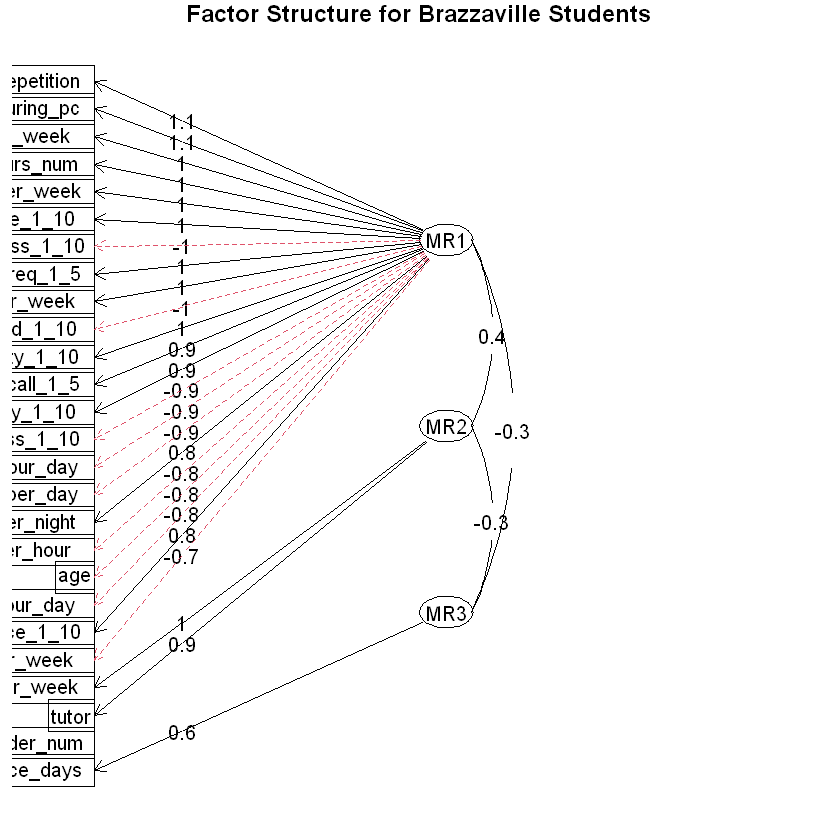

In [19]:
# 1. Performing the Factor Analysis
# We use 'minres' (minimum residual) factoring method, common for social sciences
efa_results <- psych::fa(fa_data_refined, 
                         nfactors = 3, 
                         rotate = "oblimin", 
                         fm = "minres")

# 2. Displaying the Factor Loading Matrix
# We suppress loadings below 0.3 for visual clarity, as per academic standards
print("--- Factor Loading Matrix (Pattern Matrix) ---")
print(efa_results$loadings, cutoff = 0.3)

# 3. Visualizing the structure
# This provides the "visual" proof the supervisor requested
psych::fa.diagram(efa_results, main = "Factor Structure for Brazzaville Students")

# 4. Total Variance Explained
# Checking how much information our 3 factors capture from the original data
print("--- Variance Accounted For ---")
efa_results$Vaccounted

### Consolidating the Reliability (Alpha) Summary
We create a final table that includes the refinement of the Environment dimension. Showing the "Before" and "After" demonstrates your methodological rigor (how you handled the outlier).

In [20]:
# Consolidating all Alpha results into a clean table
final_reliability_table <- data.frame(
  Dimension = c("Environment & Logistics (Initial)", 
                "Environment - Domestic Routine (Refined)", 
                "Psychological & Cognitive State", 
                "Habits & Methods"),
  Items_Count = c(5, 4, 6, 5),
  Cronbach_Alpha = c(0.485, 0.932, 0.977, 0.911),
  Status = c("Heterogeneous", "Excellent", "Excellent", "Excellent")
)

# Display the table
print("--- TABLE 1: RELIABILITY SUMMARY ---")
print(final_reliability_table)

[1] "--- TABLE 1: RELIABILITY SUMMARY ---"
                                 Dimension Items_Count Cronbach_Alpha
1        Environment & Logistics (Initial)           5          0.485
2 Environment - Domestic Routine (Refined)           4          0.932
3          Psychological & Cognitive State           6          0.977
4                         Habits & Methods           5          0.911
         Status
1 Heterogeneous
2     Excellent
3     Excellent
4     Excellent


In [21]:
# Extract loadings and convert to data frame
loading_matrix <- as.data.frame(unclass(efa_results$loadings))

# Clean the matrix: round to 3 decimals and handle small values
loading_matrix <- round(loading_matrix, 3)

# Display the matrix
print("--- TABLE 2: FACTOR LOADING MATRIX (PATTERN MATRIX) ---")
print(loading_matrix)

[1] "--- TABLE 2: FACTOR LOADING MATRIX (PATTERN MATRIX) ---"
                               MR1    MR2    MR3
study_during_pc              1.053 -0.194  0.246
study_quiet_place_1_10       1.004  0.015  0.085
study_interruption_per_hour -0.830 -0.060  0.288
sleep_hour_per_night         0.832  0.078 -0.279
sleep_quality_1_10           0.963  0.105  0.053
stress_1_10                 -0.992 -0.018 -0.010
technostress_1_10           -0.930 -0.163 -0.025
cognitive_load_1_10         -0.978 -0.008  0.037
resilience_1_10              0.799  0.088 -0.298
digital_education_hour_week  1.007  0.040  0.089
social_media_hour_day       -0.810 -0.083  0.316
ai_use_req_1_5               0.988  0.059  0.138
commute_hour_day            -0.889 -0.086  0.118
hour_searching_per_week     -0.699 -0.103  0.452
active_recall_1_5            0.948  0.088  0.005
self_test_per_week           1.006 -0.089 -0.010
past_test_hour_per_week      0.987  0.023  0.013
tutor                        0.025  0.932  0.035
tutor_h

In [ ]:
# Saving the tables for easy access
write.csv(final_reliability_table, "reliability_results.csv", row.names = FALSE)
write.csv(loading_matrix, "factor_loadings.csv")

print("Files 'reliability_results.csv' and 'factor_loadings.csv' have been generated.")